In [60]:
import pandas as pd
import glob
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np

In [61]:
###
# All variables releated data is filled here to make an order
###
PATH="C:\\Users\\emirc\\Desktop\\AAR\\data\\csv\\datas/*" #Refer the path having the csv files
ANIMALS_USED=[1]   #Animal numbers to study on 
COLUMNS_REMOVE=['Mx','My','Mz','Gx','Gy','Gz',] #Columns to delete such as Gx Gy Gz
ACTIVITIES_MERGE={'running-natural': 'running',
                 'running-rider': 'running',
                  'trotting-natural': 'trotting',    #Having nearly the same meaning
                  'trotting-rider': 'trotting',} 


In [62]:
def createDataFrame(filePaths):
    dataFrame=pd.DataFrame()
    for fileName in filePaths:
        csv=pd.read_csv(fileName,low_memory=False)
        dataFrame=dataFrame.append(csv)

    #Removing needless horses
    dataFrame=dataFrame[dataFrame['subject'].isin(ANIMALS_USED)]
    
    #Removing columns
    dataFrame.drop(COLUMNS_REMOVE,axis=1,inplace=True)
    
    #Merging activities
    for key in ACTIVITIES_MERGE:
        dataFrame['label'] = dataFrame['label'].replace(to_replace=key, value=ACTIVITIES_MERGE.get(key))
       
    #deleting unlabeled data
    dataFrame=dataFrame[~(dataFrame['label'].isin(['unknown']))]
    
    #removing nulls
    dataFrame=dataFrame.dropna(axis=0, how='any')
    return dataFrame

In [63]:
def lowBufferFiltering(dataFrame):
    sos = signal.butter(N=3, Wn=30, btype='lowpass', fs=100, output='sos')
    dataFrame['Ax'] = signal.sosfilt(sos, dataFrame['Ax'])
    dataFrame['Ay'] = signal.sosfilt(sos, dataFrame['Ay'])
    dataFrame['Az'] = signal.sosfilt(sos, dataFrame['Az'])
    return dataFrame
    

In [64]:
filePaths = sorted(glob.glob(PATH))


In [65]:
dataFrame=createDataFrame(filePaths)
#not to lose labels
labels=dataFrame.columns

#filtering
dataFrame=lowBufferFiltering(dataFrame)
#converting dataframe from numpy array
dataFrame=pd.DataFrame(dataFrame,columns=labels)


In [66]:
with open("C:\\Users\\emirc\\Desktop\\AAR\\output", 'a') as f:
    dataFrameAsString = dataFrame.to_string()
    f.write(dataFrameAsString)

    

<AxesSubplot:>

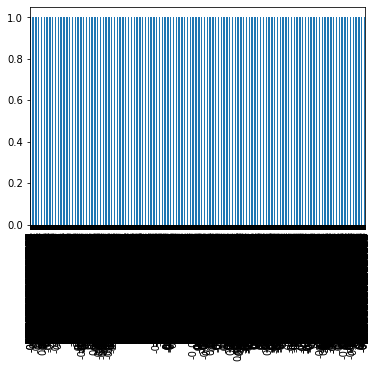

In [67]:
fig, ax = plt.subplots()
dataFrame['Ax'].value_counts().plot(ax=ax, kind='bar')

In [69]:
plt.show()